<a href="https://colab.research.google.com/github/mstagomori/desafio-ciencia-dados-inoa/blob/main/desafio_estagio_em_ciencia_de_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Abacaxi Capital Management & Equities (ACME) - Rotulação de Notícias Financeiras

## Objetivo
O Objetivo deste projeto é utilizar um modelo preditivo tradicional para rotular textos de acordo com o conteúdo do corpo e comparar seu desempenho com o de Large Language Models modernos (LLMs).

In [225]:
# Importa bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt

In [226]:
# importa dados de data/Dataset.tsv
url = "https://raw.githubusercontent.com/mstagomori/desafio-ciencia-dados-inoa/main/data/Dataset.tsv"

df = pd.read_csv(url, sep="\t")

df.head()

,id,headline,text,asset_class
0,1,Milho fecha em alta com clima adverso em regia...,Milho fecha em alta com clima adverso em regia...,commodities
1,2,"Certificado de deposito bancario oferece 9,6% ...","Certificado de deposito bancario oferece 9,6% ...",fixed_income
2,3,Aprovacao de fundo negociado de criptoativos i...,Aprovacao de fundo negociado de criptoativos i...,crypto
3,4,AeroBras surpreendeu o mercado com margem EBIT...,AeroBras surpreendeu o mercado com margem EBIT...,equities
4,5,Investidores institucionais ampliam exposicao ...,Investidores institucionais ampliam exposicao ...,crypto


## Analise Exploratória

In [227]:
# Valores nulos
df.isnull().sum()

,0
id,0
headline,0
text,0
asset_class,0


### Valores Duplicados (Headline e Text)

In [228]:
# Retorna headlines duplicados
df[df.duplicated(subset='headline', keep=False)]

,id,headline,text,asset_class
0,1,Milho fecha em alta com clima adverso em regia...,Milho fecha em alta com clima adverso em regia...,commodities
2,3,Aprovacao de fundo negociado de criptoativos i...,Aprovacao de fundo negociado de criptoativos i...,crypto
3,4,AeroBras surpreendeu o mercado com margem EBIT...,AeroBras surpreendeu o mercado com margem EBIT...,equities
4,5,Investidores institucionais ampliam exposicao ...,Investidores institucionais ampliam exposicao ...,crypto
5,6,Milho fecha em alta com clima adverso em regia...,Milho fecha em alta com clima adverso em regia...,commodities
...,...,...,...,...
5991,5992,Tesouro nacional realiza leilao de titulos pre...,Tesouro nacional realiza leilao de titulos pre...,fixed_income
5992,5993,TelecomOnda reportou queda de 1% no lucro do u...,TelecomOnda reportou queda de 1% no lucro do u...,equities
5994,5995,Empresa capta R$ 36 bilhoes em emissao de debe...,Empresa capta R$ 36 bilhoes em emissao de debe...,fixed_income
5997,5998,ImobiliariaVicta recebeu recomendacao de compr...,IMOBILIARIAVICTA RECEBEU RECOMENDACAO DE COMPR...,crypto


In [229]:
# Retorna text duplicados
df[df.duplicated(subset='text', keep=False)]

,id,headline,text,asset_class
29,30,Preco da soja sobe na bolsa de graos com quebr...,Preco da soja sobe na bolsa de graos com quebr...,commodities
39,40,Tesouro nacional realiza leilao de titulos pre...,Tesouro nacional realiza leilao de titulos pre...,fixed_income
103,104,Rendimento do titulo prefixado avanca com aber...,Rendimento do titulo prefixado avanca com aber...,fixed_income
114,115,Cartel de produtores anuncia corte de producao...,Cartel de produtores anuncia corte de producao...,commodities
138,139,Governo emite titulos publicos de longo prazo ...,Governo emite titulos publicos de longo prazo ...,fixed_income
...,...,...,...,...
5916,5917,BelaCosmeticos surpreendeu o mercado com marge...,BelaCosmeticos surpreendeu o mercado com marge...,equities
5926,5927,Aprovacao de fundo negociado de criptoativos i...,Aprovacao de fundo negociado de criptoativos i...,crypto
5927,5928,Acucar recua na bolsa de acucar com melhora na...,Acucar recua na bolsa de acucar com melhora na...,commodities
5930,5931,GAS NATURAL SOBE COM ONDA DE FRIO NO HEMISFERI...,Gas natural sobe com onda de frio no hemisferi...,commodities


In [230]:
# Registros com Text duplicados
print("Número de registros duplicados:", df[df.duplicated(subset=['text'], keep=False)].shape[0])

# Remove duplicados mantendo o primeiro registro
df = df.drop_duplicates(subset=['text'], keep='first')

Número de registros duplicados: 304


In [231]:
print(df['asset_class'].value_counts())

asset_class
equities        2001
fixed_income    1390
fx              1063
commodities      831
crypto           553
Name: count, dtype: int64


Como registros duplicados não contribuem com informação relevante para o modelo, os duplicados foram removidos, mantendo o primeiro

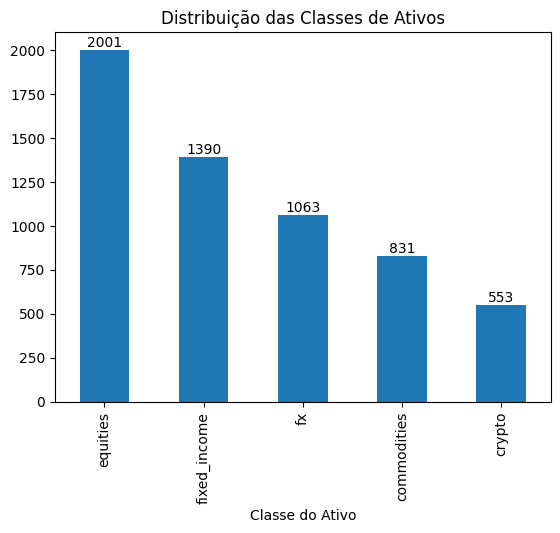

In [232]:
# PLota Distribuição de classes
df['asset_class'].value_counts().plot(kind='bar')
plt.xlabel('Classe do Ativo')
plt.title('Distribuição das Classes de Ativos')
for index, value in enumerate(df['asset_class'].value_counts()):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()

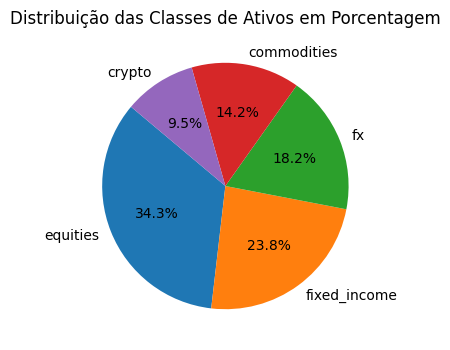

In [233]:
# Distribuição de classes em porcentagem
classes_porcentagem = df['asset_class'].value_counts(normalize=True) * 100

# Plota a distribuição de classes em pie plot
plt.figure(figsize=(4, 4))
plt.pie(classes_porcentagem, labels=classes_porcentagem.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribuição das Classes de Ativos em Porcentagem')
plt.show()

Pode-se perceber um desbalanceamento de classes, com equities e fixed_income tomando mais de 50% dos dados e crypto apenas 9.5%

Para contornar este desbalanceamento, será utilizado o parametro de pesos 'balanced' no modelo preditivo.

## Pre-Processamento

### Jargões
Utilizando uma função para identificar jargões financeiros compostos de mais de uma palvra e uní-los com _ para que o modelo os compreenda como apenas uma palavra. \
A lista de jargões foi gerada através de GenAI, utilizando o dataset como input para buscar por jargões do mercado financeiro, e posteriormente analisada.

In [234]:
financial_jargons = [
    "ações ordinárias",
    "ações preferenciais",
    "curva de juros",
    "receita líquida",
    "lucro líquido",
    "margem EBITDA",
    "renda fixa",
    "indexado à inflação",
    "fundo de renda fixa",
    "dólar comercial",
    "fluxo cambial",
    "Banco Central",
    "política monetária",
    "dívida pública",
    "fluxo estrangeiro",
    "gestores de fundos",
    "mesas de operação",
    "taxa básica",
    "juros futuros",
    "mercado de ações",
    "mercado cambial"
]

In [235]:
def replace_multiword_jargons(text, jargons):
    for jargon in jargons:
        if " " in jargon:
            replacement = jargon.replace(" ", "_")

            text = text.replace(
                jargon,
                replacement
            )

    return text

In [236]:
# Criando nova variável com jargoes compostos unidos por '_'
df["text_processed"] = df["text"].apply(
    lambda x: replace_multiword_jargons(
        x,
        financial_jargons
    )
)

In [237]:
X = df[['headline', 'text', 'text_processed']].copy()
y = df['asset_class'].copy()

In [238]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

In [239]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    ngram_range=(1, 3)
)

X_train_vector = vectorizer.fit_transform(X_train['text_processed'])
X_test_vector = vectorizer.transform(X_test['text_processed'])

## Modelos Preditivos

### Logistic Regression

In [240]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced', # balanceamento de classes, favorecendo classes com poucos registros, como crypto
    random_state=123
)

lr_model.fit(X_train_vector, y_train)

lr_pred = lr_model.predict(X_test_vector)

lr_accuracy = accuracy_score(y_test, lr_pred)

print(f"Accuracy Score Logistic Regression: {lr_accuracy:.4f}")

Accuracy Score Logistic Regression: 0.8955


### NLP (BERT)

In [241]:
import torch

# Check para execução em GPU
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
Tesla T4


In [242]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [243]:
from sklearn.preprocessing import LabelEncoder

# Codifica as classes (transforma em números) para que o modelo BERT entenda
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['commodities' 'crypto' 'equities' 'fixed_income' 'fx']


In [244]:
from datasets import Dataset

# Cria datasets de treino e teste
train_dataset = Dataset.from_dict({
    "text": X_train["text_processed"].tolist(),
    "label": y_train_encoded.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X_test["text_processed"].tolist(),
    "label": y_test_encoded.tolist()
})

In [245]:
from transformers import AutoTokenizer

# Modelo BERT pré-treinado utilizado para português brasileiro
model_name = "neuralmind/bert-base-portuguese-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [246]:
# Tokenização do texto
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=256
    )

In [247]:
# Datasets tokenizados
train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/4670 [00:00<?, ? examples/s]

Map:   0%|          | 0/1168 [00:00<?, ? examples/s]

In [248]:
from transformers import AutoModelForSequenceClassification

#  Modelo pré-treinado
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

In [249]:
from transformers import DataCollatorWithPadding

# Batch de treinamento
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [250]:
from transformers import TrainingArguments

# Argumentos de treinamento
training_args = TrainingArguments(
    output_dir="./bert_financial",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    fp16=True,

    report_to="none"
)

In [251]:
from transformers import Trainer

# Configuraçãod o Trainer, que treina o modelo
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,

    data_collator=data_collator
)

In [252]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.663349,0.522467
2,0.592835,0.515782
3,0.583395,0.520689


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1752, training_loss=0.6040922539419236, metrics={'train_runtime': 253.9358, 'train_samples_per_second': 55.171, 'train_steps_per_second': 6.899, 'total_flos': 757555160947884.0, 'train_loss': 0.6040922539419236, 'epoch': 3.0})

In [253]:
import numpy as np

predictions = trainer.predict(test_tokenized)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

In [254]:
from sklearn.metrics import accuracy_score

bert_accuracy = accuracy_score(
    y_test_encoded,
    y_pred
)

print(f"BERTimbau Accuracy: {bert_accuracy:.4f}")

BERTimbau Accuracy: 0.8955


O modelo BERT e Logistic Regression tiveram exatamente a mesma acurácia, por isso foi feita uma investigação mais profunda sobre o caso

In [255]:
results = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "BERTimbau"
    ],
    "accuracy": [
        lr_accuracy,
        bert_accuracy
    ]
})

results = results.sort_values(
    "accuracy",
    ascending=False
)

results

,model,accuracy
0,Logistic Regression,0.895548
1,BERTimbau,0.895548


Investigando sobre as predições dos modelos, pode-se printar a confiança de cada modelo nas escolhas

In [256]:
bert_pred_ids = np.argmax(predictions.predictions, axis=1)

bert_pred = np.array([
    model.config.id2label[i]
    for i in bert_pred_ids
])

id2label = {
    0: 'commodities',
    1: 'crypto',
    2: 'equities',
    3: 'fixed_income',
    4: 'fx'
}

bert_pred = np.array([
    id2label[i]
    for i in bert_pred_ids
])

In [257]:
lr_proba = lr_model.predict_proba(X_test_vector)

lr_confidence = lr_proba.max(axis=1)

from scipy.special import softmax

bert_proba = softmax(
    predictions.predictions,
    axis=1
)

bert_confidence = bert_proba.max(axis=1)

comparison_confidence = pd.DataFrame({
    "lr_pred": lr_pred,
    "lr_confidence": lr_confidence,
    "bert_pred": bert_pred,
    "bert_confidence": bert_confidence,
    "real": y_test.values
})

print(comparison_confidence.head(20))

         lr_pred  lr_confidence     bert_pred  bert_confidence          real
0       equities       0.706410      equities         0.954374      equities
1       equities       0.892269      equities         0.958600      equities
2       equities       0.736092      equities         0.955726      equities
3    commodities       0.821876   commodities         0.944196   commodities
4    commodities       0.867898   commodities         0.949118            fx
5             fx       0.855115            fx         0.962075            fx
6   fixed_income       0.787451  fixed_income         0.954638  fixed_income
7    commodities       0.876473   commodities         0.960552   commodities
8    commodities       0.781051   commodities         0.960842   commodities
9   fixed_income       0.782702  fixed_income         0.955954  fixed_income
10      equities       0.787793      equities         0.957834      equities
11  fixed_income       0.779211  fixed_income         0.958203  fixed_income

Agora pode-se dizer que os modelos realmente fizeram predições independentes, provavelmente com os mesmos critérios, porém com diferentes índices de confiança, com o BERT muito mais confiante nas escolhas que o Logistic Regression.

## Validação

In [258]:
# Pipeline
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=20000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=123
        )
    )
])

lr_pipeline.fit(
    X_train["text_processed"],
    y_train
)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=123))])

In [259]:
def validate(dataframe):
    df = dataframe.copy()

    # Cria o texto utilizado pelo modelo
    df["text_join"] = (
        df["headline"].fillna("") + " " +
        df["text"].fillna("")
    )

    df["text_final"] = df["text_join"].apply(
        lambda x: replace_multiword_jargons(
          x,
          financial_jargons
        )
    )

    df["asset_class"] = lr_pipeline.predict(
        df["text_final"]
    )

    return df

In [262]:
# Valores preditos pelo modelo
predicted_data = validate(X_test)

# Cria DataFrame com y_test (valores reais de asset_class) e valores preditos
comparison = pd.DataFrame({
    "real": y_test,
    "predicted": predicted_data["asset_class"].values
})


# Separa apenas erros de predição
errors = comparison[
    comparison["real"] != comparison["predicted"]
].copy()


print(f"Total de amostras: {len(comparison)}")
print(f"Total de erros: {len(errors)}")
print(
    f"Acurácia: "
    f"{(len(comparison) - len(errors)) / len(comparison):.4f}"
)

# Matriz de Confusão
confusion = pd.crosstab(
    errors["real"],
    errors["predicted"],
    rownames=["Real"],
    colnames=["Predito"]
)

print("\nMatriz de confusão dos erros:")
print(confusion)

# Erros por classe
errors_by_class = (
    errors["real"]
    .value_counts()
    .rename("errors")
)

print("\nErros por classe:")
print(errors_by_class)

# Taxa de erros por classe
total_by_class = (
    comparison["real"]
    .value_counts()
    .rename("total")
)

error_analysis = pd.concat(
    [
        total_by_class,
        errors_by_class
    ],
    axis=1
).fillna(0)

error_analysis["error_rate"] = (
    error_analysis["errors"]
    / error_analysis["total"]
)

error_analysis["error_rate_%"] = (
    error_analysis["error_rate"] * 100
)

error_analysis = error_analysis.sort_values(
    "error_rate",
    ascending=False
)

print("\nAnálise de erros por classe:")
print(error_analysis)

# 5 exemplos de erros
error_indices = errors.index[:5]

examples = predicted_data.loc[
    error_indices
].copy()

examples["real"] = df.loc[
    error_indices,
    "asset_class"
].values

examples["predicted"] = examples["asset_class"]

examples = examples[
    [
        "headline",
        "text_processed",
        "real",
        "predicted"
    ]
]

examples.drop(
    columns=["headline"],
    inplace=True
)

print("\n5 exemplos de erros:")
print(
    examples.to_string(index=False) # para printar texto completo
)

Total de amostras: 1168
Total de erros: 123
Acurácia: 0.8947

Matriz de confusão dos erros:
Predito       commodities  crypto  equities  fixed_income  fx
Real                                                         
commodities             0       4        11             5   4
crypto                  4       0        15            12   1
equities                4       2         0             9   4
fixed_income            2       3        13             0   1
fx                      5       0        13            11   0

Erros por classe:
real
crypto          32
fx              29
commodities     24
equities        19
fixed_income    19
Name: errors, dtype: int64

Análise de erros por classe:
              total  errors  error_rate  error_rate_%
real                                                 
crypto          111      32    0.288288     28.828829
commodities     166      24    0.144578     14.457831
fx              213      29    0.136150     13.615023
fixed_income    278      19 

A maior taxa de erros se encontra na classe 'crypto', o que era esperado devido ao desbalanceamento das classes, sendo crypto apenas 9,5% dos dados.

## Exemplos de erros de classificação

### Exemplo 1

**Real:** `fx`  
**Predito:** `commodities`

> Cobre sobe com expectativa de demanda por transicao energetica. O preco da commodity influencia diretamente o setor de energia. Especialistas divergem sobre os impactos de medio prazo.

**Explicação:** A palavra commodity pode ter induzido o modelo. No entanto, é válido lembrar que esta notícia está duplicada nos dados, contento asset_class tanto fx como commodities. Este caso faz mais sentido para commodities do que para Forex, podendo indicar uma anomalia nos dados.

---

### Exemplo 2

**Real:** `fx`  
**Predito:** `equities`

> Banco Nacional Unido teve o rating rebaixado por casa de analise apos resultado abaixo do consenso. O papel da companhia foi destaque no mercado de acoes. Analistas reforcam a recomendacao sobre as acionistas da empresa. O fato relevante foi divulgado apos o fechamento do mercado.

**Explicação:** Acionistas, mercado de acoes podem ter implicado ao tema de equities
---

### Exemplo 3

**Real:** `fx`  
**Predito:** `fixed_income`

> Empresa capta R$ 19,5 bilhoes em emissao de debentures incentivadas. O movimento afeta diretamente aplicacoes em taxa basica de juros. Gestores avaliam o impacto sobre a renda_fixa. O anuncio veio em linha com as expectativas de parte do mercado.

**Explicação:** renda_fixa induziu à classe de fixed_income - este caso também faz mais sentido o valor predito que o real, podendo ser também uma anomalia
---

### Exemplo 4

**Real:** `equities`  
**Predito:** `fixed_income`

> Certificado de deposito bancario oferece 6,0% do indice interbancario para captar liquidez. O movimento afeta diretamente aplicacoes em taxa basica de juros. Gestores avaliam o impacto sobre a divida publica. Especialistas divergem sobre os impactos de medio prazo.

**Explicação:** Taxa basica de juros pode ter induzido o modelo a classificar como fixed_income.
---

### Exemplo 5

**Real:** `crypto`  
**Predito:** `equities`

> BelaCosmeticos recebeu recomendacao de compra de analistas com preco-alvo elevado. O papel da companhia foi destaque no mercado de acoes. Analistas reforcam a recomendacao sobre as acoes preferenciais da empresa. Especialistas divergem sobre os impactos de medio prazo.

**Explicação:** Este faz mais sentido como equities do que crypto, indicando outra possível anomalia.

## Reflexão sobre GenAI: Utilizar API de LLM
Caso a ACME optasse por utilizar uma API de LLM, como GPT ou Gemini, há vantagens no poder preditivo mais alto, especialmente em modelos pagos. Entretanto, visto que notícias em tempo real devem ser rapidamente encaminhadas para as mesas durante o pregão, a latência mais alta dos modelos de LLM, principalmente sendo acessados via API, superam os prós para o caso, sendo mais vantajoso utilizar modelos menos robustos e complexos que apresentem latência dentro dos limites aceitáveis. Além disso, modelos de LLM mais precisos são pagos. Em cenários de alto fluxo de notícias e, portanto, de gasto de tokens, podem implicar em custos adicionais desnecessários.

## Uso de IA no desenvolvimento do notebook
Foi utilizada GenAI para auxiliar no desenvolvimento de código e nomenclaturas de objetos e funções, bibliotecas, geração de gráficos e estilização de Markdown.